In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  GridSearchCV


#Loading Dataset
df = pd.read_csv("RT_IOT2022.csv")
df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [44]:
df.columns

Index(['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'proto', 'service',
       'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max', 'flow_pkts_payload.

In [45]:
df.isnull().sum()

Unnamed: 0              0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64

In [46]:
# # Remove only non-essential columns
# df = df.drop(columns=[
#     'Unnamed: 0',
#     'service', 
#     'fwd_bulk_bytes', 'bwd_bulk_bytes',
#     'fwd_bulk_packets', 'bwd_bulk_packets',
#     'fwd_bulk_rate', 'bwd_bulk_rate',
#     'fwd_subflow_pkts', 'bwd_subflow_pkts',
#     'fwd_subflow_bytes', 'bwd_subflow_bytes',
#     'active.min', 'active.max', 'active.tot', 'active.avg', 'active.std',
#     'idle.min', 'idle.max', 'idle.tot', 'idle.avg', 'idle.std',
#     'payload_bytes_per_second'
# ])

# # Select features matching capture_traffic.py metrics
# features = [
#     'flow_duration',
#     'fwd_pkts_tot',
#     'bwd_pkts_tot',
#     'fwd_data_pkts_tot',
#     'bwd_data_pkts_tot',
#     'fwd_iat.avg',
#     'bwd_iat.avg',
#     'flow_pkts_per_sec'
# ]
df = df[[
    'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot',
    'fwd_data_pkts_tot', 'bwd_data_pkts_tot',
    'fwd_iat.avg', 'bwd_iat.avg', 'flow_pkts_per_sec',
    'Attack_type'
]].rename(columns={
    'flow_duration': 'duration',
    'fwd_pkts_tot': 'fwd_packets',
    'bwd_pkts_tot': 'bwd_packets',
    'fwd_data_pkts_tot': 'fwd_bytes',
    'bwd_data_pkts_tot': 'bwd_bytes',
    'fwd_iat.avg': 'fwd_iat_avg',
    'bwd_iat.avg': 'bwd_iat_avg',
    'flow_pkts_per_sec': 'packet_rate'
})

In [47]:
# X = df.drop('Attack_type', axis=1)
# y = df['Attack_type']
print(df['Attack_type'].value_counts())
df.shape

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64


(123117, 9)

In [48]:
normal_labels = ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb', 'Amazon-Alexa']

attack_labels = df['Attack_type'].unique().tolist()
attack_labels = [x for x in attack_labels if x not in normal_labels]

In [49]:
X_normal = df[df['Attack_type'].isin(normal_labels)].drop('Attack_type', axis=1)
X_attack = df[df['Attack_type'].isin(attack_labels)].drop('Attack_type', axis=1)

print(f"Normal samples: {len(X_normal)}")  # Should output 96,249
print(f"Attack samples: {len(X_attack)}")  # Should output 128,110

Normal samples: 12507
Attack samples: 110610


In [50]:
# Or create synthetic DNS-like flows
dns_pattern = {
    'duration': 0.05,  # 50ms
    'fwd_packets': 1,
    'bwd_packets': 1,
    'fwd_bytes': 100,
    'bwd_bytes': 200,
    'fwd_iat_avg': 0.01,
    'bwd_iat_avg': 0.01,
    'packet_rate': 40  # 2 packets/0.05s
}
# Add synthetic normal examples for common protocols
def add_protocol_examples(X_normal):
    # HTTPS examples
    https_examples = pd.DataFrame([{
        'duration': np.random.uniform(0.5, 10),
        'fwd_packets': np.random.randint(5, 50),
        'bwd_packets': np.random.randint(5, 50),
        'fwd_bytes': np.random.randint(1000, 50000),
        'bwd_bytes': np.random.randint(1000, 50000),
        'fwd_iat_avg': np.random.uniform(0.01, 0.1),
        'bwd_iat_avg': np.random.uniform(0.01, 0.1),
        'packet_rate': np.random.uniform(5, 100)
    } for _ in range(2000)])
    
    # mDNS examples
    mdns_examples = pd.DataFrame([{
        'duration': np.random.uniform(0.01, 0.1),
        'fwd_packets': 1,
        'bwd_packets': 0,
        'fwd_bytes': np.random.randint(100, 300),
        'bwd_bytes': 0,
        'fwd_iat_avg': 0.01,
        'bwd_iat_avg': 0,
        'packet_rate': 100  # High rate acceptable for multicast
    } for _ in range(500)])
    
    return pd.concat([X_normal, https_examples, mdns_examples])

X_normal = add_protocol_examples(X_normal)
X_dns = pd.DataFrame([dns_pattern]*1000)  # Add 1000 DNS examples
X_normal = pd.concat([X_normal, X_dns])


print(f"Normal samples: {len(X_normal)}")  # Should output 96,249
print(f"Attack samples: {len(X_attack)}")  

Normal samples: 16007
Attack samples: 110610


In [51]:
from sklearn.model_selection import train_test_split
# 80% normal for training, 20% for validation
X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=38
)

In [52]:
_, X_test_normal = train_test_split(X_normal, test_size=0.2, random_state=38)
X_test_attack = X_attack.sample(frac=0.2, random_state=38)

# Combine for testing
X_test = pd.concat([X_test_normal, X_test_attack])
y_test = np.array([0]*len(X_test_normal) + [1]*len(X_test_attack))  # 0=normal, 1=attack

In [53]:
from sklearn.preprocessing import MinMaxScaler

# Scale 
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)
# # Save the scaler for inference
# import joblib
# joblib.dump(scaler, 'rtiot_scaler.pkl')

In [54]:
# Re-save your scaler after training with:
import joblib
from sklearn import __version__
print(__version__)  # Should be 1.6.1
joblib.dump(scaler, 'rtiot_scaler.pkl')

1.6.1


['rtiot_scaler.pkl']

In [55]:
# In training script
print(X_train.columns.tolist())  # Must match FEATURE_ORDER

['duration', 'fwd_packets', 'bwd_packets', 'fwd_bytes', 'bwd_bytes', 'fwd_iat_avg', 'bwd_iat_avg', 'packet_rate']


In [56]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Define the model architecture
input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation='relu')(input_layer)
encoder = Dropout(0.1)(encoder)
encoder_output = Dense(8, activation='relu')(encoder)

decoder = Dense(16, activation='relu')(encoder_output)
decoder = Dropout(0.1)(decoder)
decoder_output = Dense(input_dim, activation='sigmoid')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder_output)
autoencoder.compile(optimizer='adam', loss='mse')

#  Callbacks
checkpoint = ModelCheckpoint(
    'autoencoder_model.keras',
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-5
)

# Model Summary
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560 (2.19 KB)

 Trainable params: 560 (2.19 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Train the model with callbacks
history = autoencoder.fit(X_train_scaled, X_train_scaled,
                          epochs=50,
                          batch_size=256,
                          validation_data=(X_val_scaled, X_val_scaled),
                          callbacks=[checkpoint, reduce_lr],
                          verbose=1)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2291 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1653 - val_loss: 0.1048 - learning_rate: 0.0010
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0622 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0202 - val_loss: 0.0358 - learning_rate: 0.0010
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0121 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0096 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0063 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - val_loss: 0.0267 - learning_rate: 0.0010
Epoch 10/50
51/51 ━━━

In [58]:
val_reconstructions = autoencoder.predict(X_val_scaled)
val_mae = np.mean(np.abs(X_val_scaled - val_reconstructions), axis=1)
threshold = np.percentile(val_mae, 99.5) 

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [59]:
# Save threshold value
with open('threshold.txt', 'w') as f:
    f.write(str(threshold))

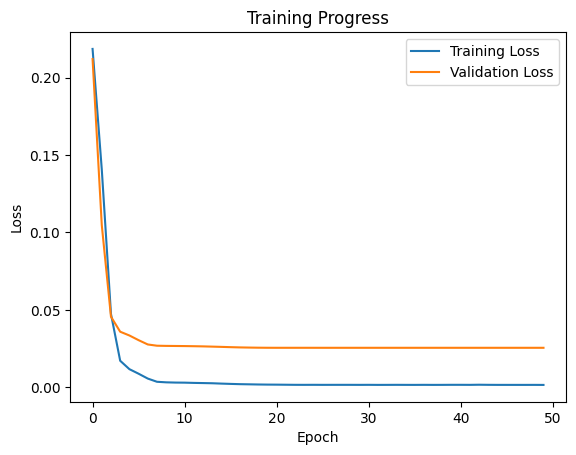

In [60]:
import matplotlib.pyplot as plt

# Evaluation plots
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [61]:
# Reconstruct test data
reconstructions = autoencoder.predict(X_test_scaled)

# Calculate MAE for each sample
mae = np.mean(np.abs(X_test_scaled - reconstructions), axis=1)
# Classify based on threshold
y_pred = (mae > threshold).astype(int)  # 1=anomaly, 0=normal

792/792 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [62]:
from sklearn.metrics import accuracy_score

# Compare predictions to ground truth
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8439
